# Baseline CNN

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models
from torchvision.models import ResNet18_Weights
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits

In [14]:
df = pd.read_csv("../data/all_tracks_clean.csv")

df.head()

,genre,id,title,artist,album,duration_sec,rank,explicit,isrc,track_position,bpm,gain,contributors,num_contributors,tier
0,Pop,3602074142,Choosin' Texas,Ella Langley,Choosin' Texas,232,831096,False,USSM12504190,1,0.0,-8.3,Ella Langley (Main),1,9
1,Pop,3763842212,I Just Might,Bruno Mars,I Just Might,213,995346,False,USAT22509144,1,0.0,-10.4,Bruno Mars (Main),1,10
2,Pop,3503857201,Man I Need,Olivia Dean,Man I Need,184,991622,False,GBUM72503089,1,0.0,-8.7,Olivia Dean (Main),1,10
3,Pop,3881984641,American Girls,Harry Styles,"Kiss All The Time. Disco, Occasionally.",213,997062,False,USSM12600097,2,0.0,-8.3,Harry Styles (Main),1,10
4,Pop,3579685911,The Fate of Ophelia,Taylor Swift,The Life of a Showgirl,226,836426,False,USUG12506436,1,0.0,-8.5,Taylor Swift (Main),1,9


In [15]:
df['tier'] = (df['tier']+1)//2-1

In [16]:
df['tier'].value_counts()

tier
0    2255
2    1843
1    1725
3    1253
4     547
Name: count, dtype: int64

In [17]:
df.shape

(7623, 15)

In [18]:
image_data = np.load("../data/spectrogram_tensors.npz")

X = image_data["X"]
indices = image_data["indices"]

# repeat grayscale channel 3x so pretrained ResNet weights transfer correctly
# (avoids replacing conv1 with random weights)
X = np.repeat(X, 3, axis=1)  # (N, 1, H, W) → (N, 3, H, W)

In [19]:
y_raw = df.iloc[indices]["tier"].values.astype(int)
classes = np.unique(y_raw)
num_classes = len(classes)
label_map = {c: i for i, c in enumerate(sorted(classes))}
y = np.array([label_map[v] for v in y_raw])

In [20]:
# verify labels are correct integers aligned with spectrograms
for label_idx, orig_tier in enumerate(sorted(classes)):
    print(f"label {label_idx} (tier {orig_tier}): {(y == label_idx).sum()} samples")

label 0 (tier 0): 2234 samples
label 1 (tier 1): 1707 samples
label 2 (tier 2): 1834 samples
label 3 (tier 3): 1236 samples
label 4 (tier 4): 538 samples


In [21]:
X.shape, y.shape

((7549, 3, 128, 128), (7549,))

In [22]:
from sklearn.model_selection import train_test_split

#Train/Test/Val Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=6500)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=6500)

In [23]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(5284, 3, 128, 128) (5284,)
(1132, 3, 128, 128) (1132,)
(1133, 3, 128, 128) (1133,)


In [24]:
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

def to_tensor_dataset(X, y):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_t, y_t)

train_ds = to_tensor_dataset(X_train, y_train)
val_ds   = to_tensor_dataset(X_val,   y_val)
test_ds  = to_tensor_dataset(X_test,  y_test)

# Use class weights in the loss instead of resampling — avoids overfitting to rare classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

In [25]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes - 1)
)

# Freeze everything except layer3, layer4, and fc
for name, param in model.named_parameters():
    param.requires_grad = any(name.startswith(k) for k in ['layer3', 'layer4', 'fc'])

In [26]:
device = torch.device("mps")
model  = model.to(device)

In [27]:
backbone_params = [p for name, p in model.named_parameters()
                   if p.requires_grad and not name.startswith('fc')]
head_params = list(model.fc.parameters())

optimizer = torch.optim.Adam([
    {'params': backbone_params, 'lr': 1e-4},
    {'params': head_params,     'lr': 1e-3},
], weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

In [28]:
def train_epoch(model, loader):
    model.train()
    total_loss, total_correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, dtype=torch.float32)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = corn_loss(logits, y_batch, num_classes)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = corn_label_from_logits(logits)
        total_correct += (preds == y_batch).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

def eval_epoch(model, loader):
    model.eval()
    total_loss, total_correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, dtype=torch.float32)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            total_loss += corn_loss(logits, y_batch, num_classes).item()
            preds = corn_label_from_logits(logits)
            total_correct += (preds == y_batch).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

In [29]:
EPOCHS        = 100
PATIENCE      = 5

In [30]:
# Single training loop — no warmup phase needed since full network trains from the start
print("=== Training (full network, differential LR) ===")
best_val_loss    = float("inf")
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss,   val_acc   = eval_epoch(model, val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered")
            break

=== Training (full network, differential LR) ===
Epoch 01 | Train loss: 0.6424  Acc: 0.2443 | Val loss: 0.6279  Acc: 0.2438
Epoch 02 | Train loss: 0.5870  Acc: 0.3350 | Val loss: 0.6401  Acc: 0.2580
Epoch 03 | Train loss: 0.4831  Acc: 0.5100 | Val loss: 0.7059  Acc: 0.2845
Epoch 04 | Train loss: 0.3390  Acc: 0.6928 | Val loss: 0.8415  Acc: 0.2862
Epoch 05 | Train loss: 0.1590  Acc: 0.8704 | Val loss: 1.0840  Acc: 0.2933
Epoch 06 | Train loss: 0.0994  Acc: 0.9273 | Val loss: 1.1603  Acc: 0.2880
Early stopping triggered


In [31]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(device, dtype=torch.float32))
        all_preds.append(corn_label_from_logits(logits).cpu().numpy())
        all_targets.append(y_batch.numpy())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

acc = (all_preds == all_targets).mean()
mae = np.abs(all_preds - all_targets).mean()
print(f"Test Accuracy: {acc:.4f} | Test Ordinal MAE: {mae:.4f}")

Test Accuracy: 0.2657 | Test Ordinal MAE: 1.0132


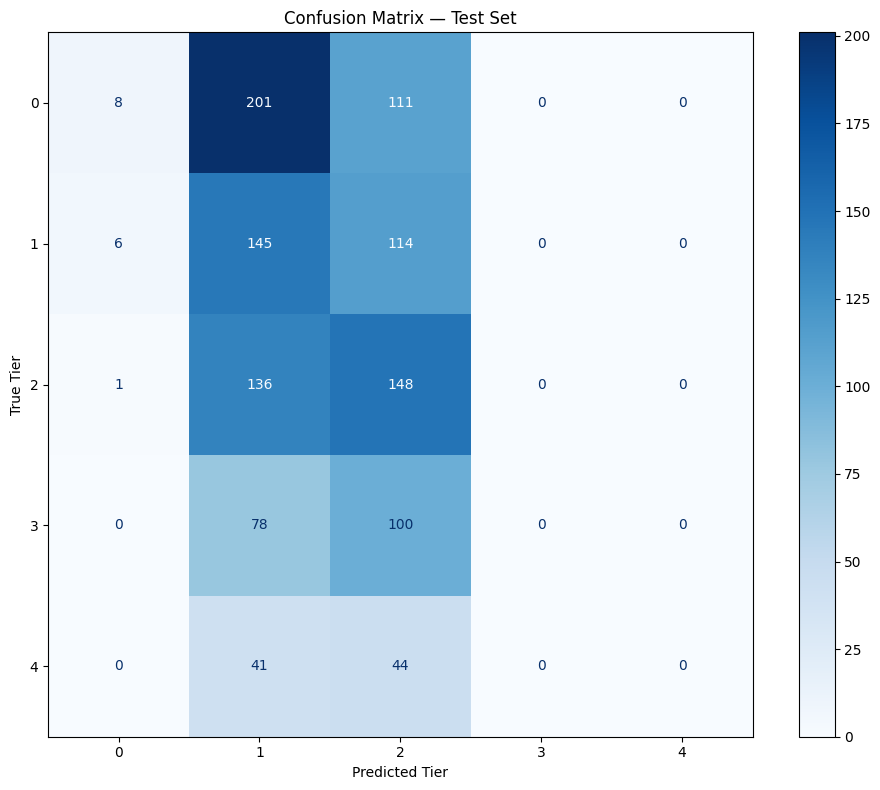

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tier_labels = [str(c) for c in sorted(classes)]
cm = confusion_matrix(all_targets, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tier_labels)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set")
ax.set_xlabel("Predicted Tier")
ax.set_ylabel("True Tier")
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150)
plt.show()